In [15]:
import json
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt


def flatten_result(d):
    """Flatten nested result dict into a flat dict."""
    flat = {}

    # top-level scalar metadata already embedded in JSON
    for key in ['type', 'epoch', 'run', 'forget_set_type', 'unlearning_item',
                'method', 'epoch_duration', 'total_unlearning_time_up_to_now', 'ToW']:
        if key in d:
            flat[key] = d[key]

    # nested metric dicts -> {split}_{metric} columns (e.g. forget_acc, retain_loss)
    for metric in ['acc', 'loss', 'entropy', 'm_entropy']:
        if metric in d:
            for split, val in d[metric].items():
                flat[f'{split}_{metric}'] = val

    # threshold_MIA -> threshold_MIA.{path} columns
    if 'threshold_MIA' in d:
        mia_flat = pd.json_normalize(d['threshold_MIA'], sep='.')
        for col in mia_flat.columns:
            flat[f'threshold_MIA.{col}'] = mia_flat[col].iloc[0]

    # outputs -> outputs.{path} columns
    if 'outputs' in d:
        out_flat = pd.json_normalize(d['outputs'], sep='.')
        for col in out_flat.columns:
            flat[f'outputs.{col}'] = out_flat[col].iloc[0]

    return flat


def gather_results(results_folder,
                   epochs=None, classes=None, percents=None, runs=None, methods=None,
                   base=True, retrain=True):

    # collect all result json files
    all_files = []
    for root, dirs, files in os.walk(results_folder):
        for fname in files:
            if fname.endswith('.json') and 'config' not in fname:
                all_files.append(os.path.join(root, fname))

    def norm(f):
        return f.replace('\\', '/')

    if not base:
        all_files = [f for f in all_files if '/base/' not in norm(f)]
    if not retrain:
        all_files = [f for f in all_files if '/retrain/' not in norm(f)]

    if classes is not None:
        pattern = rf"class_({'|'.join(map(str, classes))})"
        all_files = [f for f in all_files if re.search(pattern, f)]
    if percents is not None:
        pattern = rf"percent_({'|'.join(map(str, percents))})"
        all_files = [f for f in all_files if re.search(pattern, f)]

    all_rows = []
    for f in all_files:
        with open(f) as fh:
            d = json.load(fh)

        flat = flatten_result(d)

        # class and percent from filename
        m = re.search(r'class_(\d+)', f)
        flat['class'] = int(m.group(1)) if m else -99
        m = re.search(r'percent_(\d+)', f)
        flat['percent'] = int(m.group(1)) if m else -99

        # fill sentinel epoch/run/method for base and retrain (not embedded in those JSONs)
        result_type = flat.get('type', 'unknown')
        if result_type == 'base':
            flat.setdefault('epoch', -99)
            flat.setdefault('run', -99)
            flat.setdefault('method', 'base')
        elif result_type == 'retrain':
            flat.setdefault('epoch', -98)
            flat.setdefault('method', 'retrain')
            m = re.search(r'retrain_run_(\d+)', norm(f))
            flat.setdefault('run', int(m.group(1)) if m else -99)

        all_rows.append(flat)

    if not all_rows:
        raise ValueError("No results - check settings")

    final_df = pd.DataFrame(all_rows)

    # post-load filters (epoch/run/method live in JSON, not path)
    if epochs is not None:
        final_df = final_df[final_df['epoch'].isin(epochs)]
    if runs is not None:
        final_df = final_df[final_df['run'].isin(runs)]
    if methods is not None:
        keep = set(methods) | {'base', 'retrain'}
        final_df = final_df[final_df['method'].isin(keep)]

    if final_df.empty:
        raise ValueError("No results after filtering - check settings")

    return final_df


def results_scatterplot(final_df, x_metric, y_metric,
                        color_by="epoch",
                        base_color="black", retain_color="purple"):

    unique_vals = sorted(final_df[color_by].unique(), key=str)
    colors_list = plt.cm.tab20.colors
    palette_dict = {}
    color_idx = 0
    for val in unique_vals:
        if val == -99 or val == "base":
            palette_dict[val] = base_color
        elif val == -98 or val == "retrain":
            palette_dict[val] = retain_color
        else:
            palette_dict[val] = colors_list[color_idx % len(colors_list)]
            color_idx += 1

    plt.clf()
    sns.set_style("whitegrid")
    sns.scatterplot(
        data=final_df,
        x=x_metric,
        y=y_metric,
        hue=color_by,
        palette=palette_dict,
        alpha=0.7,
        edgecolor=None
    )
    plt.title(f"{x_metric} vs. {y_metric}")
    plt.xlabel(x_metric.capitalize().replace("_", " "))
    plt.ylabel(y_metric.capitalize().replace("_", " "))
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = ["base" if l in ("-99", "-99.0") else "retrain" if l in ("-98", "-98.0") else l for l in labels]
    plt.legend(title=color_by.capitalize(), handles=handles, labels=new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [16]:
def results_table(results):
    """
    Summarise forget_acc, retain_acc, and test_acc for every method in `results`,
    showing mean ± std across runs.  For unlearning methods the last available
    epoch per run is used as the reported result.
    """
    metrics     = ['forget_acc', 'retain_acc', 'test_acc', 'ToW']
    col_labels  = {
        'forget_acc': 'Forget Acc (%)',
        'retain_acc': 'Retain Acc (%)',
        'test_acc':   'Test Acc (%)',
        'ToW': 'Tug-of-War (#)'
    }

    def fmt(mean, std=None):
        if std is None or pd.isna(std) or std == 0:
            return f"{mean:.2f}"
        return f"{mean:.2f} ± {std:.2f}"

    rows = []

    # --- base (single model, no std) ---
    base_df = results[results['type'] == 'base']
    if not base_df.empty:
        row = {'Method': 'base'}
        for m in metrics:
            row[col_labels[m]] = fmt(base_df[m].mean())
        rows.append(row)

    # --- retrain (mean ± std across retrain runs) ---
    retrain_df = results[results['type'] == 'retrain']
    if not retrain_df.empty:
        row = {'Method': 'retrain'}
        for m in metrics:
            row[col_labels[m]] = fmt(retrain_df[m].mean(), retrain_df[m].std())
        rows.append(row)

    # --- unlearning methods (last epoch per run, then mean ± std across runs) ---
    unlearn_df = results[results['type'] == 'unlearn'].dropna(subset=['method'])
    for method_name in unlearn_df['method'].unique():
        method_df = unlearn_df[unlearn_df['method'] == method_name].copy()
        last_epoch_per_run = method_df.groupby('run')['epoch'].max().rename('last_epoch')
        method_df = method_df.join(last_epoch_per_run, on='run')
        method_df = method_df[method_df['epoch'] == method_df['last_epoch']]

        row = {'Method': method_name}
        for m in metrics:
            row[col_labels[m]] = fmt(method_df[m].mean(), method_df[m].std())
        rows.append(row)

    return pd.DataFrame(rows).set_index('Method')


In [17]:
results = gather_results("results/seed_5", base=True, retrain=True) 
results

,type,forget_acc,retain_acc,test_acc,forget_loss,retain_loss,test_loss,forget_entropy,retain_entropy,test_entropy,...,epoch_duration,total_unlearning_time_up_to_now,ToW,outputs.retrained_vs_unlearned.forget.absolute_distance,outputs.retrained_vs_unlearned.forget.l2_distance,outputs.retrained_vs_unlearned.forget.JS_divergence,outputs.retrained_vs_unlearned.retain.absolute_distance,outputs.retrained_vs_unlearned.test.absolute_distance,outputs.retrained_vs_unlearned.forget_test_avg.KL_divergence,outputs.unlearned.forget_vs_test.wasserstein_distance
0,base,99.88,99.826667,92.93,0.004231,0.005898,0.339403,0.010177,0.010872,0.055142,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,retrain,91.56,99.846667,92.69,0.354726,0.005395,0.362473,0.084553,0.011685,0.060765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,retrain,91.48,99.851111,92.32,0.357891,0.005572,0.370638,0.081307,0.011456,0.059518,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,retrain,91.90,99.868889,92.35,0.351269,0.005124,0.367397,0.079292,0.011441,0.059774,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,unlearn,99.78,99.788889,92.79,0.007837,0.006456,0.350213,0.012976,0.012290,0.054721,...,9.813936,49031.402588,0.916413,1.797847,1.256282,0.619370,1.799379,0.132724,13.568683,0.342382
5,unlearn,99.76,99.757778,92.82,0.005766,0.007318,0.357399,0.011041,0.011338,0.051778,...,9.889675,98098.997355,0.916050,1.812036,1.266962,0.624121,1.798182,0.135048,13.877159,0.351638
6,unlearn,99.92,99.857778,92.93,0.004050,0.005221,0.339350,0.009990,0.010863,0.055144,...,1.581450,4704.325438,0.914364,1.811946,1.266785,0.624465,1.800593,0.131813,13.206399,0.335309
7,unlearn,99.82,99.866667,92.96,0.005523,0.004821,0.339172,0.009619,0.010644,0.055165,...,1.549889,7812.898397,0.915163,1.805286,1.262633,0.621760,1.795999,0.131797,13.174937,0.333658
8,unlearn,99.82,99.851111,92.80,0.006414,0.005523,0.362508,0.011306,0.010706,0.053071,...,18.853322,94250.305176,0.916493,1.788339,1.250576,0.615549,1.801428,0.132941,13.713210,0.356100
9,unlearn,99.86,99.813333,92.82,0.006034,0.006427,0.363350,0.012253,0.011524,0.051012,...,17.843000,185380.058527,0.915565,1.800571,1.258659,0.620092,1.804020,0.134291,14.029481,0.357321


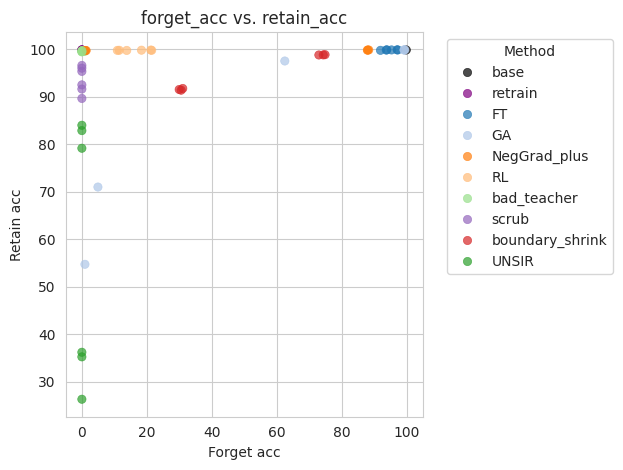

In [42]:
results = gather_results("results/seed_4", base=True, retrain=True)
results_scatterplot(
    results, 
    x_metric = "forget_acc", y_metric = "retain_acc", 
    color_by = "method"
    )

In [45]:
results = gather_results("results/seed_5", base=True, retrain=True)
results_table(results)

,Forget Acc (%),Retain Acc (%),Test Acc (%),Tug-of-War (#)
Method,,,,
base,99.88,99.83,92.93,nan
retrain,91.65 ± 0.22,99.86 ± 0.01,92.45 ± 0.21,nan
FT,99.83 ± 0.07,99.80 ± 0.04,92.79 ± 0.04,0.92 ± 0.00
GA,99.85 ± 0.03,99.84 ± 0.02,92.95 ± 0.01,0.91 ± 0.00
NegGrad_plus,99.81 ± 0.08,99.78 ± 0.05,92.85 ± 0.09,0.92 ± 0.00
RL,99.73 ± 0.14,99.74 ± 0.00,92.80 ± 0.08,0.92 ± 0.00
bad_teacher,98.49 ± 0.82,99.30 ± 0.38,91.04 ± 1.70,0.92 ± 0.01
scrub,94.29 ± 0.52,96.73 ± 0.43,91.23 ± 0.28,0.93 ± 0.00
boundary_shrink,99.80 ± 0.03,99.70 ± 0.04,92.57 ± 0.03,0.92 ± 0.00


NameError: name 'base_out' is not defined

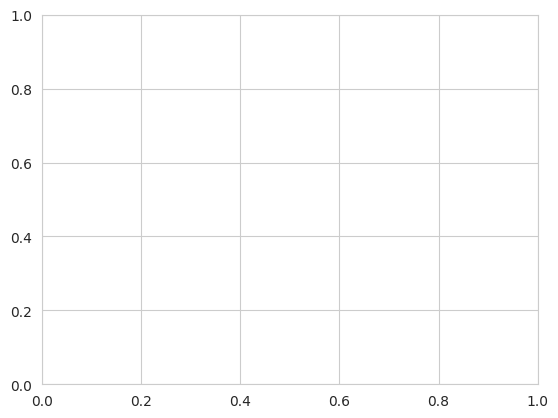

In [20]:
import torch

def entropy_chart(dataset = "forget"):

    fig, ax = plt.subplots()

    ax.hist(torch.log(base_out[dataset]["entropies"]).numpy(),      bins=50, alpha=0.6, label="base")
    ax.hist(torch.log(unlearned_out[dataset]["entropies"]).numpy(), bins=50, alpha=0.6, label="unlearned")
    ax.hist(torch.log(retrained_out[dataset]["entropies"]).numpy(), bins=50, alpha=0.6, label="retrained")

    ax.set_xlabel("Entropy")
    ax.set_ylabel("Count")
    ax.set_title(f"Entropy Distribution - {dataset}")
    ax.legend()
    plt.tight_layout()
    plt.show()

entropy_chart("forget")
entropy_chart("retain")
entropy_chart("test")